# Beat Saber Map Classifier — Test Notebook

Enter any BeatSaver map key to classify it. The key is the short hex ID in the URL:
`https://beatsaver.com/maps/**2b120**`

Maps are downloaded on first use and cached in `data/raw/maps_test/`.

In [17]:
import io, json, sys, zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import onnxruntime as rt
import pandas as pd
import requests

sys.path.insert(0, str(Path.cwd().parent))
from src.data.map_parser import find_beatmap_file, parse_beatmap, compute_pattern_features

CATEGORY_COLORS = {
    'Speed':    '#e74c3c',
    'Tech':     '#9b59b6',
    'Accuracy': '#2ecc71',
    'Extreme':  '#e67e22',
    'Standard': '#3498db',
}

## Configuration — edit this cell

In [18]:
# BeatSaver map key (the short hex ID from the URL)
MAP_KEY = "4b4a8"

# Difficulty and characteristic to analyse
# Difficulty: Easy / Normal / Hard / Expert / ExpertPlus
# Characteristic: Standard / OneSaber / NoArrows / 90Degree / 360Degree
DIFFICULTY      = "ExpertPlus"
CHARACTERISTIC  = "Standard"

CACHE_DIR  = Path("../data/raw/maps_test")   # separate from training maps
MODEL_DIR  = Path("../models")

## Load model

In [19]:
meta_path = MODEL_DIR / "onnx" / "pattern_classifier_meta.json"
onnx_path = MODEL_DIR / "onnx" / "pattern_classifier.onnx"

model_meta     = json.loads(meta_path.read_text())
feature_names  = model_meta["features"]
classes        = model_meta["classes"]
imputer_medians = np.array(model_meta["imputer_medians"])
scaler_mean    = np.array(model_meta["scaler_mean"])
scaler_scale   = np.array(model_meta["scaler_scale"])

sess = rt.InferenceSession(str(onnx_path))
inp_name = sess.get_inputs()[0].name

print(f"Model loaded  — classes: {classes}")
print(f"Feature count — {len(feature_names)}")

Model loaded  — classes: ['Accuracy', 'Extreme', 'Speed', 'Standard', 'Tech']
Feature count — 202


## Download map

In [20]:
HEADERS = {"User-Agent": "BSMapClassifier/1.0"}

def download_map(key: str, cache_dir: Path) -> tuple[Path, dict]:
    """Download and extract a BeatSaver map; return (map_dir, api_info)."""
    map_dir = cache_dir / key
    api_cache = map_dir / "_beatsaver.json"

    if map_dir.exists() and api_cache.exists() and any(map_dir.glob("*.dat")):
        print(f"Using cached map: {map_dir}")
        return map_dir, json.loads(api_cache.read_text())

    print(f"Fetching map info for {key}…")
    r = requests.get(f"https://beatsaver.com/api/maps/id/{key}",
                     headers=HEADERS, timeout=10)
    r.raise_for_status()
    info = r.json()

    dl_url = info["versions"][-1]["downloadURL"]
    print(f"Downloading {info['metadata']['songName']} by {info['metadata']['levelAuthorName']}…")
    r2 = requests.get(dl_url, headers=HEADERS, timeout=60)
    r2.raise_for_status()

    map_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(r2.content)) as zf:
        zf.extractall(map_dir)
    api_cache.write_text(json.dumps(info, indent=2))

    print(f"Done — extracted to {map_dir}")
    return map_dir, info


map_dir, api_info = download_map(MAP_KEY, CACHE_DIR)

meta = api_info.get("metadata", {})
print(f"\nSong:   {meta.get('songName')} — {meta.get('songAuthorName')}")
print(f"Mapper: {meta.get('levelAuthorName')}")
print(f"Diffs:  {[d['difficulty'] for v in api_info['versions'] for d in v.get('diffs', []) if d.get('characteristic') == CHARACTERISTIC]}")

Fetching map info for 4b4a8…
Done — extracted to ../data/raw/maps_test/4b4a8

Song:   Rock It — Hommarju
Mapper: Bitz
Diffs:  ['Easy', 'Normal', 'Hard', 'Expert', 'ExpertPlus']


## Parse map and extract features

In [21]:
def get_bpm(map_dir: Path) -> float:
    """Read BPM from Info.dat (v2 or v4 format)."""
    for name in ("Info.dat", "info.dat"):
        p = map_dir / name
        if p.exists():
            info = json.loads(p.read_text(encoding="utf-8"))
            # v2
            if "_beatsPerMinute" in info:
                return float(info["_beatsPerMinute"])
            # v4
            if "audio" in info:
                return float(info["audio"].get("bpm", 120))
    return 120.0


dat_path = find_beatmap_file(map_dir, CHARACTERISTIC, DIFFICULTY)
if dat_path is None:
    raise FileNotFoundError(
        f"Could not find {CHARACTERISTIC}/{DIFFICULTY} .dat file in {map_dir}.\n"
        f"Available files: {[f.name for f in map_dir.iterdir() if f.suffix == '.dat']}"
    )

bpm = get_bpm(map_dir)
notes, obstacles, arcs, chains, bombs = parse_beatmap(dat_path)
feats = compute_pattern_features(notes, obstacles, arcs, chains, bpm)

print(f"BPM:           {bpm}")
print(f"Notes parsed:  {len(notes)}")
print(f"Bombs:         {len(bombs)}")
print(f"Features:      {len(feats)}")
print(f"\nKey stats:")
for k in ['ebpm_max_overall', 'n_stream_runs', 'longest_stream', 'n_crossovers',
          'n_dd', 'n_doubles', 'crossover_rate', 'dd_rate_total']:
    v = feats.get(k, 0)
    print(f"  {k:25s} {v:.3f}" if isinstance(v, float) else f"  {k:25s} {v}")

BPM:           170.0
Notes parsed:  1191
Bombs:         0
Features:      201

Key stats:
  ebpm_max_overall          340.000
  n_stream_runs             108
  longest_stream            17
  n_crossovers              289
  n_dd                      73
  n_doubles                 224
  crossover_rate            0.243
  dd_rate_total             0.073


## Classify


  PREDICTED CATEGORY : Extreme  (87.9% confidence)



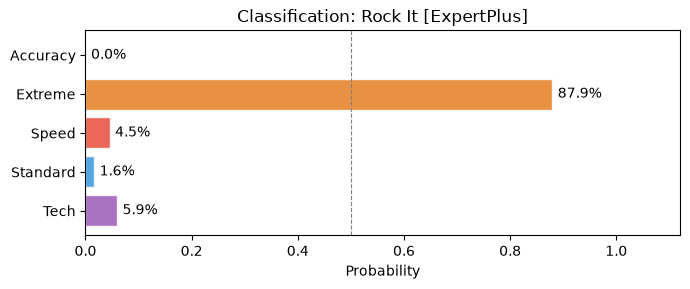

In [22]:
raw = pd.Series(feats).reindex(feature_names, fill_value=np.nan).values.reshape(1, -1)
# Apply imputer then scaler (same pipeline as export_onnx.py)
imputed    = np.where(np.isnan(raw), imputer_medians, raw)
feat_scaled = ((imputed - scaler_mean) / scaler_scale).astype(np.float32)

probs      = sess.run(None, {inp_name: feat_scaled})[1][0]
pred_idx   = int(probs.argmax())
pred_class = classes[pred_idx]
confidence = float(probs[pred_idx])

print(f"\n{'='*45}")
print(f"  PREDICTED CATEGORY : {pred_class}  ({confidence:.1%} confidence)")
print(f"{'='*45}\n")

# Probability bar chart
fig, ax = plt.subplots(figsize=(7, 3))
colors = [CATEGORY_COLORS[c] for c in classes]
bars   = ax.barh(classes, probs, color=colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=4, fontsize=10)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Probability")
ax.set_title(f"Classification: {meta.get('songName', MAP_KEY)} [{DIFFICULTY}]")
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Pattern profile vs. training distribution

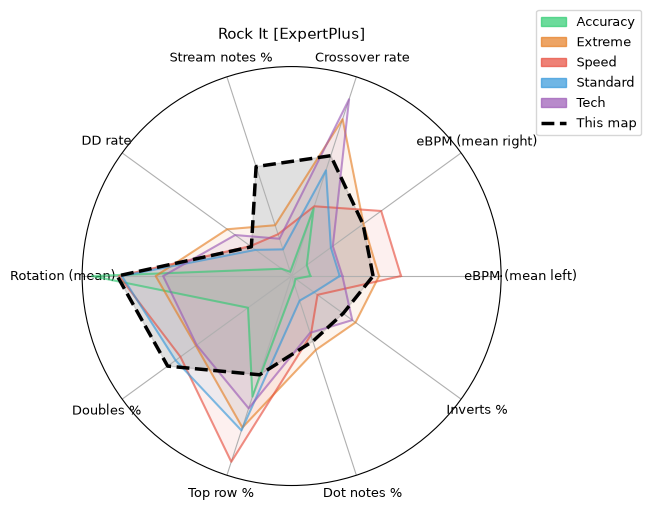

In [23]:
train_df = pd.read_csv("../data/processed/pattern_features.csv")

# Key discriminating features (from feature importance analysis)
RADAR_FEATURES = {
    "eBPM (mean left)":   "ebpm_left_mean",
    "eBPM (mean right)":  "ebpm_right_mean",
    "Crossover rate":     "crossover_rate",
    "Stream notes %":     "n_stream_notes_rate",
    "DD rate":            "dd_rate_total",
    "Rotation (mean)":    "rotation_mean_total",
    "Doubles %":          "n_doubles_rate",
    "Top row %":          "top_row_rate",
    "Dot notes %":        "dot_note_rate",
    "Inverts %":          "n_inverts_rate",
}

labels  = list(RADAR_FEATURES.keys())
cols    = list(RADAR_FEATURES.values())
N       = len(labels)
angles  = [n / N * 2 * np.pi for n in range(N)] + [0]  # close the polygon

# Normalise: per-feature min-max across training set
cat_means = train_df.groupby("category")[cols].mean()
col_min   = train_df[cols].min()
col_max   = train_df[cols].max()
col_range = (col_max - col_min).replace(0, 1)

def normalise(row):
    return ((row[cols] - col_min) / col_range).clip(0, 1).values

this_map_norm = normalise(pd.Series(feats))

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cat in classes:
    vals = normalise(cat_means.loc[cat]).tolist() + [normalise(cat_means.loc[cat])[0]]
    ax.plot(angles, vals, color=CATEGORY_COLORS[cat], linewidth=1.5, alpha=0.6)
    ax.fill(angles, vals, color=CATEGORY_COLORS[cat], alpha=0.08)

# This map
this_vals = this_map_norm.tolist() + [this_map_norm[0]]
ax.plot(angles, this_vals, color='black', linewidth=2.5, linestyle='--', label=f"This map ({pred_class})")
ax.fill(angles, this_vals, color='black', alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=9)
ax.set_yticks([])
ax.set_title(f"{meta.get('songName', MAP_KEY)} [{DIFFICULTY}]", pad=20, fontsize=11)

legend_handles = [mpatches.Patch(color=CATEGORY_COLORS[c], label=c, alpha=0.7)
                  for c in classes]
legend_handles.append(plt.Line2D([0], [0], color='black', linewidth=2.5,
                                  linestyle='--', label=f"This map"))
ax.legend(handles=legend_handles, loc='upper right',
          bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.show()

## Pattern breakdown

In [24]:
PATTERN_COUNTS = [
    ("Stream runs",        "n_stream_runs"),
    ("Longest stream",     "longest_stream"),
    ("Jump stream runs",   "n_jump_stream_runs"),
    ("Piano streams",      "n_piano_streams"),
    ("Vibro notes",        "n_vibro_notes"),
    ("Dot spam runs",      "n_dot_spam_runs"),
    ("Doubles",            "n_doubles"),
    ("Stacks",             "n_stacks"),
    ("Towers",             "n_towers"),
    ("Crossovers",         "n_crossovers"),
    ("Crossover scissors", "n_crossover_scissor"),
    ("Scissors",           "n_scissor"),
    ("Double directionals","n_dd"),
    ("Triangles",          "n_triangles"),
    ("Inline notes",       "n_inline"),
    ("Jumps",              "n_jumps"),
    ("Inverts",            "n_inverts"),
    ("Flicks",             "n_flicks"),
    ("Gallops",            "n_gallops"),
    ("Loloppes",           "n_loloppes"),
    ("Hooks",              "n_hooks"),
    ("Scoops",             "n_scoops"),
    ("Shrados",            "n_shrados"),
    ("Croissants",         "n_croissants"),
    ("Arm circles",        "n_arm_circles"),
    ("Staircases",         "n_staircases"),
    ("Flowers",            "n_flowers"),
    ("Windows",            "n_windows"),
    ("Handclaps",          "n_handclaps"),
    ("Vision blocks",      "n_vision_blocks"),
    ("Groove walls",       "n_groove_walls"),
    ("Bomb resets",        "n_bomb_resets"),
    ("Bomb holds",         "n_bomb_holds"),
    ("Hammer hits",        "n_hammer_hits"),
    ("Face notes",         "n_face_notes"),
    ("Dot notes",          "n_dot_notes"),
    ("Top-row notes",      "n_top_row_notes"),
    ("Paul",               "n_paul"),
    ("Quad",               "n_quads"),
]

train_df  = pd.read_csv("../data/processed/pattern_features.csv")
pred_mean = train_df[train_df.category == pred_class]

rows = []
for label, key in PATTERN_COUNTS:
    this_val = feats.get(key, 0)
    cat_mean = pred_mean[key].mean() if key in pred_mean.columns else 0
    all_mean = train_df[key].mean()  if key in train_df.columns  else 0
    rows.append({"Pattern": label, "This map": int(this_val),
                 f"{pred_class} avg": round(cat_mean, 1),
                 "All-cat avg": round(all_mean, 1)})

result_df = pd.DataFrame(rows).set_index("Pattern")
display(result_df.style.background_gradient(subset=["This map"], cmap="Blues"))

,This map,Extreme avg,All-cat avg
Pattern,,,
Stream runs,108,42.000000,21.700000
Longest stream,17,47.300000,27.800000
Jump stream runs,103,31.900000,13.900000
Piano streams,0,0.000000,0.000000
Vibro notes,59,49.900000,25.900000
Dot spam runs,0,0.500000,0.200000
Doubles,224,302.900000,218.100000
Stacks,14,50.600000,37.800000
Towers,6,9.100000,3.900000


## Note density over time

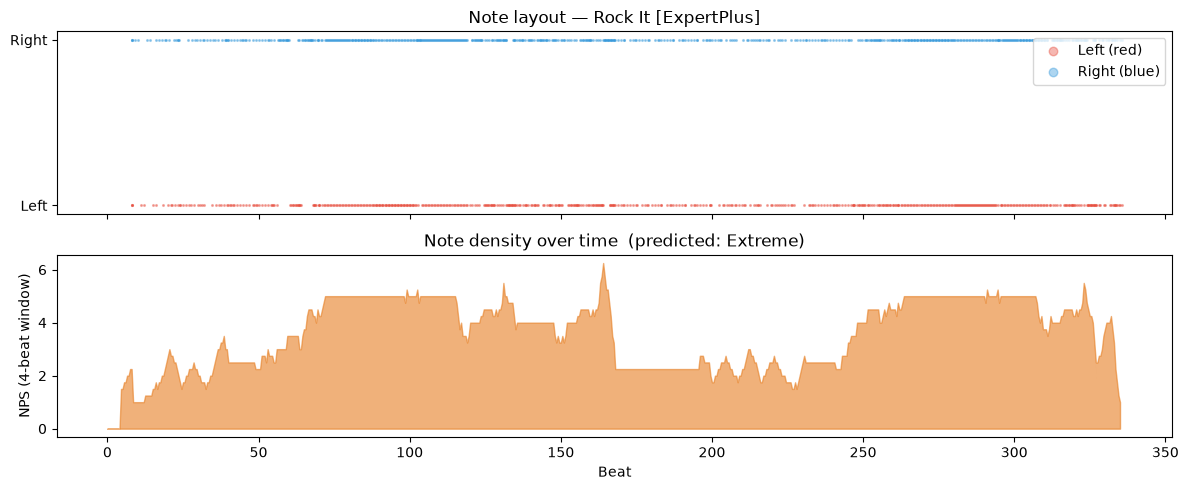

In [25]:
if not notes:
    print("No notes parsed.")
else:
    beats = np.array([n.beat for n in notes])
    colors_arr = np.array([n.color for n in notes])

    # Rolling NPS in 4-beat windows
    window = 4.0
    t_max  = beats.max()
    t_grid = np.arange(0, t_max, 0.5)
    nps    = [np.sum((beats >= t) & (beats < t + window)) / window for t in t_grid]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

    # Note scatter (red/blue by hand)
    ax1.scatter(beats[colors_arr == 0], np.zeros(np.sum(colors_arr == 0)),
                c='#e74c3c', s=1.5, alpha=0.4, label='Left (red)')
    ax1.scatter(beats[colors_arr == 1], np.ones(np.sum(colors_arr == 1)),
                c='#3498db', s=1.5, alpha=0.4, label='Right (blue)')
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Left', 'Right'])
    ax1.set_title(f"Note layout — {meta.get('songName', MAP_KEY)} [{DIFFICULTY}]")
    ax1.legend(loc='upper right', markerscale=5)

    # NPS rolling average
    ax2.fill_between(t_grid, nps, alpha=0.6, color=CATEGORY_COLORS[pred_class])
    ax2.set_ylabel("NPS (4-beat window)")
    ax2.set_xlabel("Beat")
    ax2.set_title(f"Note density over time  (predicted: {pred_class})")

    plt.tight_layout()
    plt.show()